In [5]:
import psycopg2
import matplotlib.pyplot as plt
import pandas as pd

!pip install numpy
import numpy as np

In [6]:
# Ahora vamos a extraer los datos de la base en local y analizarlos 

DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "postgres",
    "user": "postgres",
    "password": "IK008626"
}

conn = psycopg2.connect(**DB_CONFIG)

cur = conn.cursor()

cur.execute("SELECT * FROM divisas;")

filas = cur.fetchall()

nombre_columnas = [desc[0] for desc in cur.description]

cur.close()
conn.close()

In [7]:
# Pasamos los datos a un DataFrame para su análisis y visualización

df = pd.DataFrame(filas, columns=nombre_columnas)

print(df.head())

        fecha     aud     cad     chf      cyp     czk     dkk      eek  \
0  2000-11-13  1.6494  1.3293  1.5231  0.57241  34.686  7.4596  15.6466   
1  2000-11-20  1.6341  1.3106  1.5221  0.57241  34.494  7.4604  15.6466   
2  2000-11-27  1.6345  1.3208  1.5133  0.57241  34.518  7.4575  15.6466   
3  2000-12-04  1.6275  1.3647  1.5131  0.57241  34.916  7.4543  15.6466   
4  2000-12-11  1.6281  1.3441  1.5062  0.57241  34.757  7.4548  15.6466   

       gbp     hkd  ...     nzd     pln      rol     sek     sgd     sit  \
0  0.60118  6.6922  ...  2.1566  3.9236  21530.0  8.6472  1.4990  211.50   
1  0.59752  6.5914  ...  2.1263  3.8629  21293.0  8.6719  1.4840  211.72   
2  0.60554  6.7134  ...  2.1151  3.8652  21769.0  8.6946  1.5105  212.17   
3  0.61420  6.9224  ...  2.0870  3.9203  22569.0  8.6050  1.5450  212.55   
4  0.60542  6.8873  ...  2.0828  3.8652  22555.0  8.5525  1.5337  213.08   

      skk       trl      usd     zar  
0  42.747  586610.0  0.85806  6.5674  
1  42.679  583

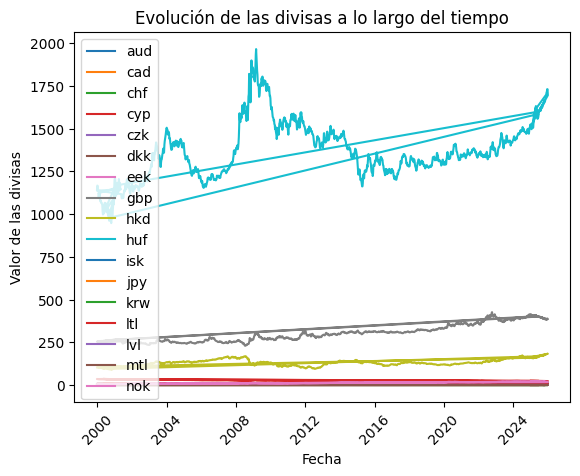

In [8]:
x = df["fecha"]
y = df.drop(columns=["fecha"])

y_filtered = y.loc[:, (y <= 400000).all()]

plt.plot(x, y_filtered)
plt.xlabel("Fecha")
plt.ylabel("Valor de las divisas")
plt.title("Evolución de las divisas a lo largo del tiempo")
plt.legend(nombre_columnas[1:], loc="upper left")
plt.xticks(rotation=45)
plt.show()

In [10]:
# Variación de valor respecto al euro

rendimiento_total = (y.iloc[0]-y.iloc[-1]) / y.iloc[-1]
print(rendimiento_total.sort_values(ascending=False))

chf    0.635421
czk    0.425999
nzd    0.073042
dkk   -0.000951
sgd   -0.004780
aud   -0.066501
pln   -0.077646
cad   -0.181566
sek   -0.212402
hkd   -0.260588
usd   -0.262201
gbp   -0.308368
nok   -0.310858
huf   -0.325080
krw   -0.407420
isk   -0.469684
jpy   -0.473291
zar   -0.671495
cyp         NaN
eek         NaN
ltl         NaN
lvl         NaN
mtl         NaN
rol         NaN
sit         NaN
skk         NaN
trl         NaN
dtype: float64


In [12]:
returns = np.log(y / y.shift(1)).dropna()

returns

,aud,cad,chf,cyp,czk,dkk,eek,gbp,hkd,huf,...,nzd,pln,rol,sek,sgd,sit,skk,trl,usd,zar
1,-0.009319,-0.014167,-0.000657,0.000000,-0.005551,0.000107,0.0,-0.006107,-0.015177,0.001704,...,-0.014150,-0.015591,-0.011069,0.002852,-0.010057,0.001040,-0.001592,-0.005564,-0.015243,0.005043
2,0.000245,0.007753,-0.005798,0.000000,0.000696,-0.000389,0.0,0.013333,0.018340,0.001965,...,-0.005281,0.000595,0.022109,0.002614,0.017700,0.002123,0.007563,0.013174,0.018338,0.009469
3,-0.004292,0.032697,-0.000132,0.000000,0.011464,-0.000429,0.0,0.014200,0.030657,0.001283,...,-0.013374,0.014155,0.036090,-0.010359,0.022583,0.001789,0.010985,0.019912,0.030842,0.014023
4,0.000369,-0.015210,-0.004571,0.000000,-0.004564,0.000067,0.0,-0.014398,-0.005083,-0.000830,...,-0.002014,-0.014155,-0.000621,-0.006120,-0.007341,0.002490,-0.004749,0.000083,-0.005128,0.009954
5,0.015541,0.027083,0.005760,0.000576,-0.000115,0.000885,0.0,0.015407,0.025997,-0.001549,...,0.002733,-0.004226,0.026988,0.018891,0.023520,0.000844,0.010391,0.014123,0.025865,0.014849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,0.105444,0.058166,-0.008307,0.011723,-0.019920,0.000979,0.0,0.027461,0.018566,0.017642,...,0.019393,-0.042335,0.179805,0.068447,0.030642,0.032394,0.025450,0.312853,0.019061,0.132729
1333,0.009575,0.011562,0.002408,0.000121,0.001010,0.000054,0.0,0.007552,0.013073,0.001578,...,0.001505,-0.005765,0.018178,0.002425,0.014200,-0.000139,0.001120,0.141955,0.013065,0.004803
1334,0.031677,0.015258,0.000780,-0.000155,0.003081,-0.000040,0.0,-0.001197,0.008892,-0.000263,...,0.027309,-0.009277,0.011938,0.001901,0.015286,0.001669,0.000639,-0.068122,0.008888,0.015376
1335,0.010504,-0.013989,-0.000910,-0.000484,-0.005593,0.000201,0.0,-0.006704,-0.019393,0.000638,...,0.007246,0.004232,-0.015828,0.010280,-0.013611,0.001435,-0.002171,0.040303,-0.019366,-0.012731
